In [810]:
import torch 
import torch.nn.functional as F

import random

import matplotlib.pyplot as plt
%matplotlib inline

# Read the words:
words = open('names.txt', 'r').read().splitlines()

# Initial Model Training

In [ ]:
# Build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}

# Build Dataset
block_size = 3 # context length: How many chars are taken to predict the next?
X, Y = [], [] 
for w in words:
    # print(w)
    context = [0] * block_size 
    
    for c in w + '.':
        ix = stoi[c]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X) ; Y = torch.tensor(Y)

In [453]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator = g)
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn(100, generator = g)
W2 = torch.randn((100, 27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, b1, W2, b2]

In [454]:
sum(p.nelement() for p in parameters)

3481

In [455]:
for p in parameters:
    p.requires_grad = True

lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre 

In [ ]:
lri = []
lossi = []

for i in range(10000):

    # Mini-batch construct 
    ix = torch.randint(0, X.shape[0], (32, ))

    # Forward Pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])

    # print(loss.item())

    # Backward Pass 
    for p in parameters: 
        p.grad = None
    loss.backward()

    # Update 

    # lr = lrs[i]
    # for p in parameters: 
    #     p.data += -lr * p.grad
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
   
    # Track stats:

    # lri.append(lre[i])
    # lossi.append(loss.item())

# print(loss.item())

In [457]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.5658, grad_fn=<NllLossBackward0>)

# Splitting Set and Training

In [811]:
# Training Split, Dev/Validation Split, Test Split 

def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size 
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [812]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator = g)
W1 = torch.randn((30, 200), generator = g)
b1 = torch.randn(200, generator = g)
W2 = torch.randn((200, 27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre 

In [813]:
lri = []
lossi = []
stepi = []

In [814]:
for i in range(200000):

    # Mini-batch construct 
    ix = torch.randint(0, Xtr.shape[0], (32, ))

    # Forward Pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # Backward Pass 
    for p in parameters: 
        p.grad = None
    loss.backward()

    # Update 
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # Track Stats
    stepi.append(i)
    lossi.append(loss.log10().item())

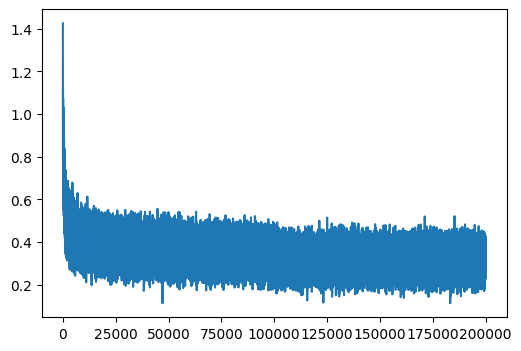

In [815]:
plt.figure(figsize = (6, 4))
plt.plot(stepi, lossi)
plt.show()

In [816]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1167, grad_fn=<NllLossBackward0>)

In [817]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1627, grad_fn=<NllLossBackward0>)

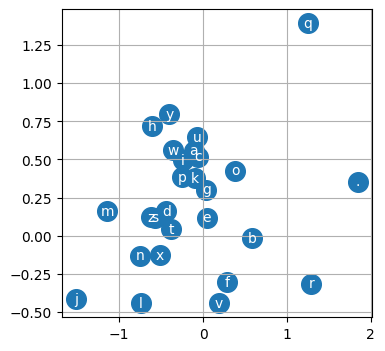

In [818]:
plt.figure(figsize = (4, 4))
plt.scatter(C[:, 0].data, C[:, 1].data, s = 200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha = "center", va = "center", color = "white")
plt.grid('minor')
plt.show()

In [819]:
# Making up names: 
for i in range(20):
    out = []
    context = [0] * block_size 

    while True: 
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0: break
    
    print(''.join(itos[i] for i in out))

sar.
giely.
kit.
abgilyn.
elup.
asziyanni.
kani.
lilee.
raeser.
les.
lidustair.
catysleer.
daylen.
nix.
felaneel.
keya.
wabigotin.
dailynn.
komy.
harlie.
